In [1]:
import numpy as np
import pickle
# Number of parameters
import matplotlib.pyplot as plt
import emcee
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.patches import Ellipse
from matplotlib.transforms import blended_transform_factory
from tqdm import tqdm_pandas, tqdm_notebook

import functions as func
from functions import adjust_angle
from mcmc import ln_prob
import radar_functions as rf
import lc_functions as lf

In [2]:
file_pick = open('mcmc_samples_2025/both_mcmc_20_02_2025_warner.obj', 'rb')
#file_pick = open('mcmc_samples_final/mcmc_full_2.obj', 'rb')
sampler = pickle.load(file_pick)

In [3]:
thin = 1
samples = sampler.get_chain(flat=True, thin=thin) * (sampler.params_max - sampler.params_min) + sampler.params_min
flat_ln = sampler.flatlnprobability[::thin][np.isfinite(sampler.flatlnprobability[::thin])]
samples = samples[np.argwhere(flat_ln != -np.inf), :][:, 0]
min_arg = flat_ln.argmax()
min_chi = flat_ln[min_arg]
print(f'len_samples_all: {len(samples)}', f'len_samples_notna: {len(samples)}')
print(f"min_arg: {min_arg}, min_chi: {min_chi}")
best_params = samples[min_arg]
print("""best_params: a1 = {:.2f},  b1 = {:.2f}, c1 = {:.2f},
             a2 = {:.2f}, b2 = {:.2f}, c2 = {:.2f},
             lon = {:.2f}, lat = {:.2f}, phase = {:.2f}""".format(*best_params))


print('best:      ', [round(float(param), 4) for param in best_params])

len_samples_all: 2388258 len_samples_notna: 2388258
min_arg: 2208031, min_chi: -42274.08635902463
best_params: a1 = 1.41,  b1 = 0.83, c1 = 0.83,
             a2 = 1.04, b2 = 1.04, c2 = 0.38,
             lon = 1.40, lat = -1.39, phase = 1.68
best:       [1.4085, 0.8296, 0.8277, 1.0403, 1.0384, 0.378, 1.4023, -1.3911, 1.676, 0.2091, 2499.6007, 2.0135]


In [4]:
n_sample = 1000
best_idxs = np.argsort(flat_ln)[::-1][:n_sample]
best_chis2 = np.sort(flat_ln)[::-1][:n_sample]
best_samples = samples[best_idxs]

(array([ 69., 326.,  79.,   0., 237., 204.,   8.,  58.,   0.,  19.]),
 array([-42274.88875424, -42274.80851472, -42274.7282752 , -42274.64803567,
        -42274.56779615, -42274.48755663, -42274.40731711, -42274.32707759,
        -42274.24683807, -42274.16659855, -42274.08635902]),
 <BarContainer object of 10 artists>)

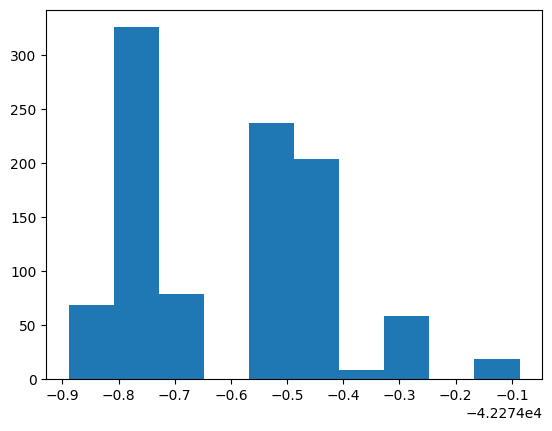

In [5]:
plt.hist(best_chis2)

<function quantile at 0x798c147cede0>


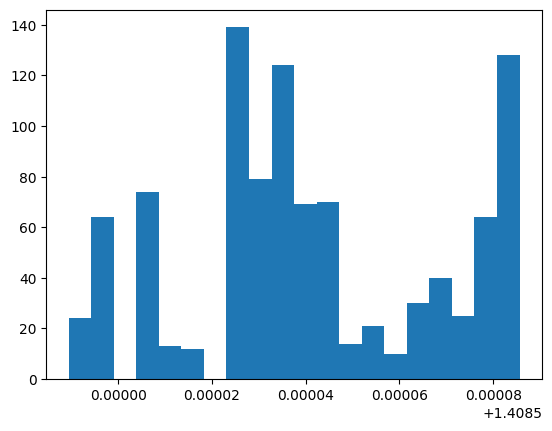

In [6]:
plt.hist(best_samples.T[0], bins=20)
print(np.quantile)

In [8]:
# calculate the radar chi2 for each sample
radar_image_params = rf.RadarImageParameters("radar_data/data.txt")
# radar_images_obs = [np.array(read_observed_radar_image(radar_image_params,idx_img)) for idx_img in range(radar_image_params.N_points)]
radar_images_obs = [rf.denoise_img(np.array(rf.read_observed_radar_image(radar_image_params,idx_img)))
                    for idx_img in range(radar_image_params.N_points)]


query_dates = [radar_image_params.jd[idx_img] + 2400000.5 for idx_img in range(len(radar_image_params.jd))]
state_vecs_earth = func.get_object_orbit('2000 WO107', epochs=query_dates,  location='@399', data_type='vectors')
state_vecs_earth['r'] = np.sum(state_vecs_earth[['x', 'y', 'z']] ** 2, axis=1)**0.5
position_vecs = (state_vecs_earth[['x', 'y', 'z']].T / state_vecs_earth['r']).T
#position_vecs.to_csv('input_data/position_vecs.csv', index=False)

In [9]:
diffs = []
for params in tqdm_notebook(best_samples):
    diff, _ = rf.radar_images_diff(params, radar_image_params, radar_images_obs, position_vecs, mult=450, lt_num=50, pow_coeff=params[-1])
    total_diff = np.sum(diff) * 3
    diffs.append(total_diff)

/tmp/ipykernel_10414/691445579.py:2: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for params in tqdm_notebook(best_samples):


  0%|          | 0/1000 [00:00<?, ?it/s]

(array([553., 114., 212.,   9.,  75.,  27.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  10.]),
 array([ 7268.03609128,  7798.12794781,  8328.21980434,  8858.31166086,
         9388.40351739,  9918.49537392, 10448.58723045, 10978.67908698,
        11508.77094351, 12038.86280004, 12568.95465657, 13099.0465131 ,
        13629.13836963, 14159.23022616, 14689.32208269, 15219.41393922,
        15749.50579574, 16279.59765227, 16809.6895088 , 17339.78136533,
        17869.87322186]),
 <BarContainer object of 20 artists>)

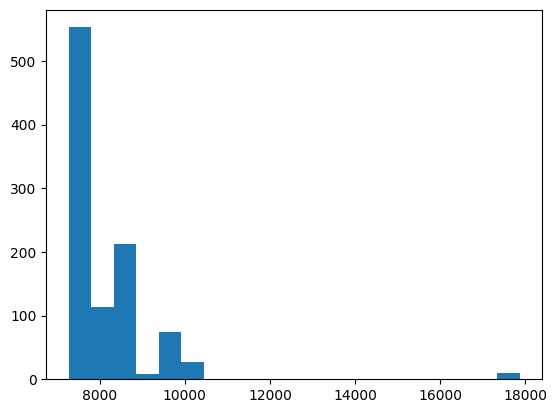

In [10]:
diffs = np.array(diffs) / 3
plt.hist(diffs, bins=20)

In [11]:
min(diffs)

np.float64(7268.036091277337)

In [4]:
flat_ln_notna = flat_ln[np.argwhere(flat_ln != -np.inf)]

In [14]:
# check autocorrelation times
autocorr = sampler.get_autocorr_time(thin=10)
print("Mean acceptance fraction:", np.mean(sampler.acceptance_fraction))

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 160;
tau: [         nan 408.18150715          nan 527.59290619 331.95702181
 280.63083362 172.77368987          nan          nan          nan
 418.08896598 262.09344231]

In [7]:
print("Mean acceptance fraction:", np.mean(sampler.acceptance_fraction))

Mean acceptance fraction: 0.0014203750000000002


(0.0, 50000.0)

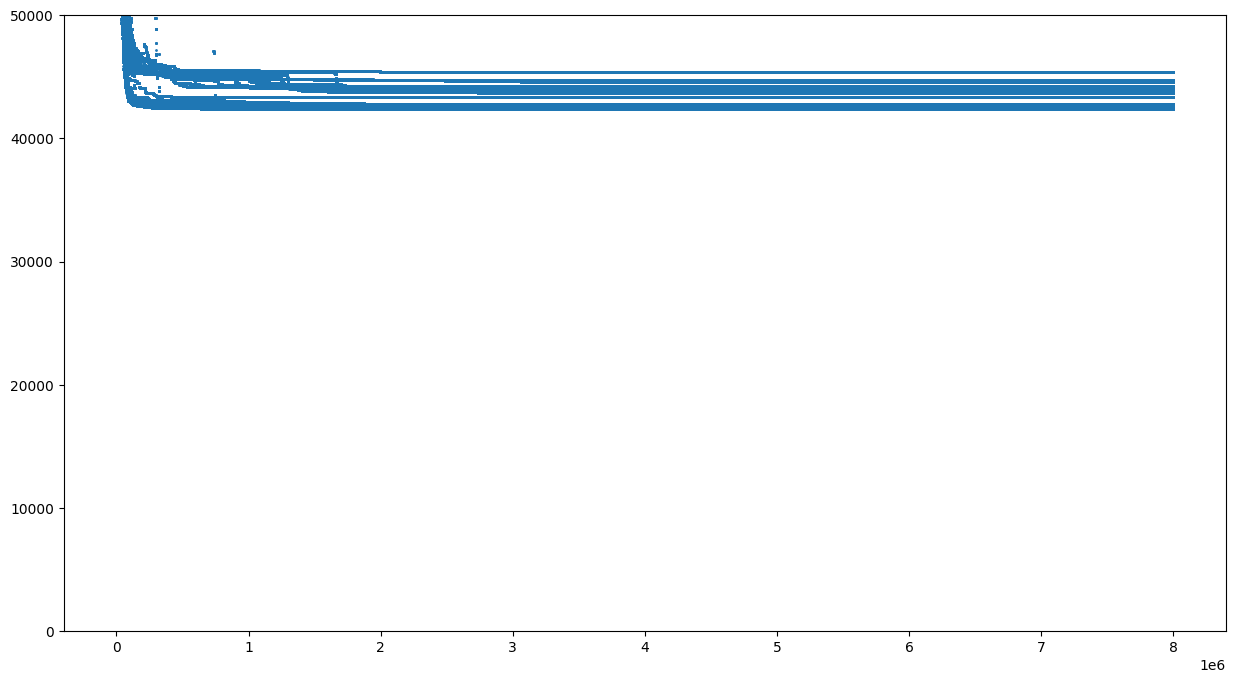

In [8]:
plt.figure(figsize=(15, 8))
x = [i for i in range(len(flat_ln))]
plt.scatter(x, -flat_ln, s=1)
plt.ylim(0, 50000)

100 8000 12


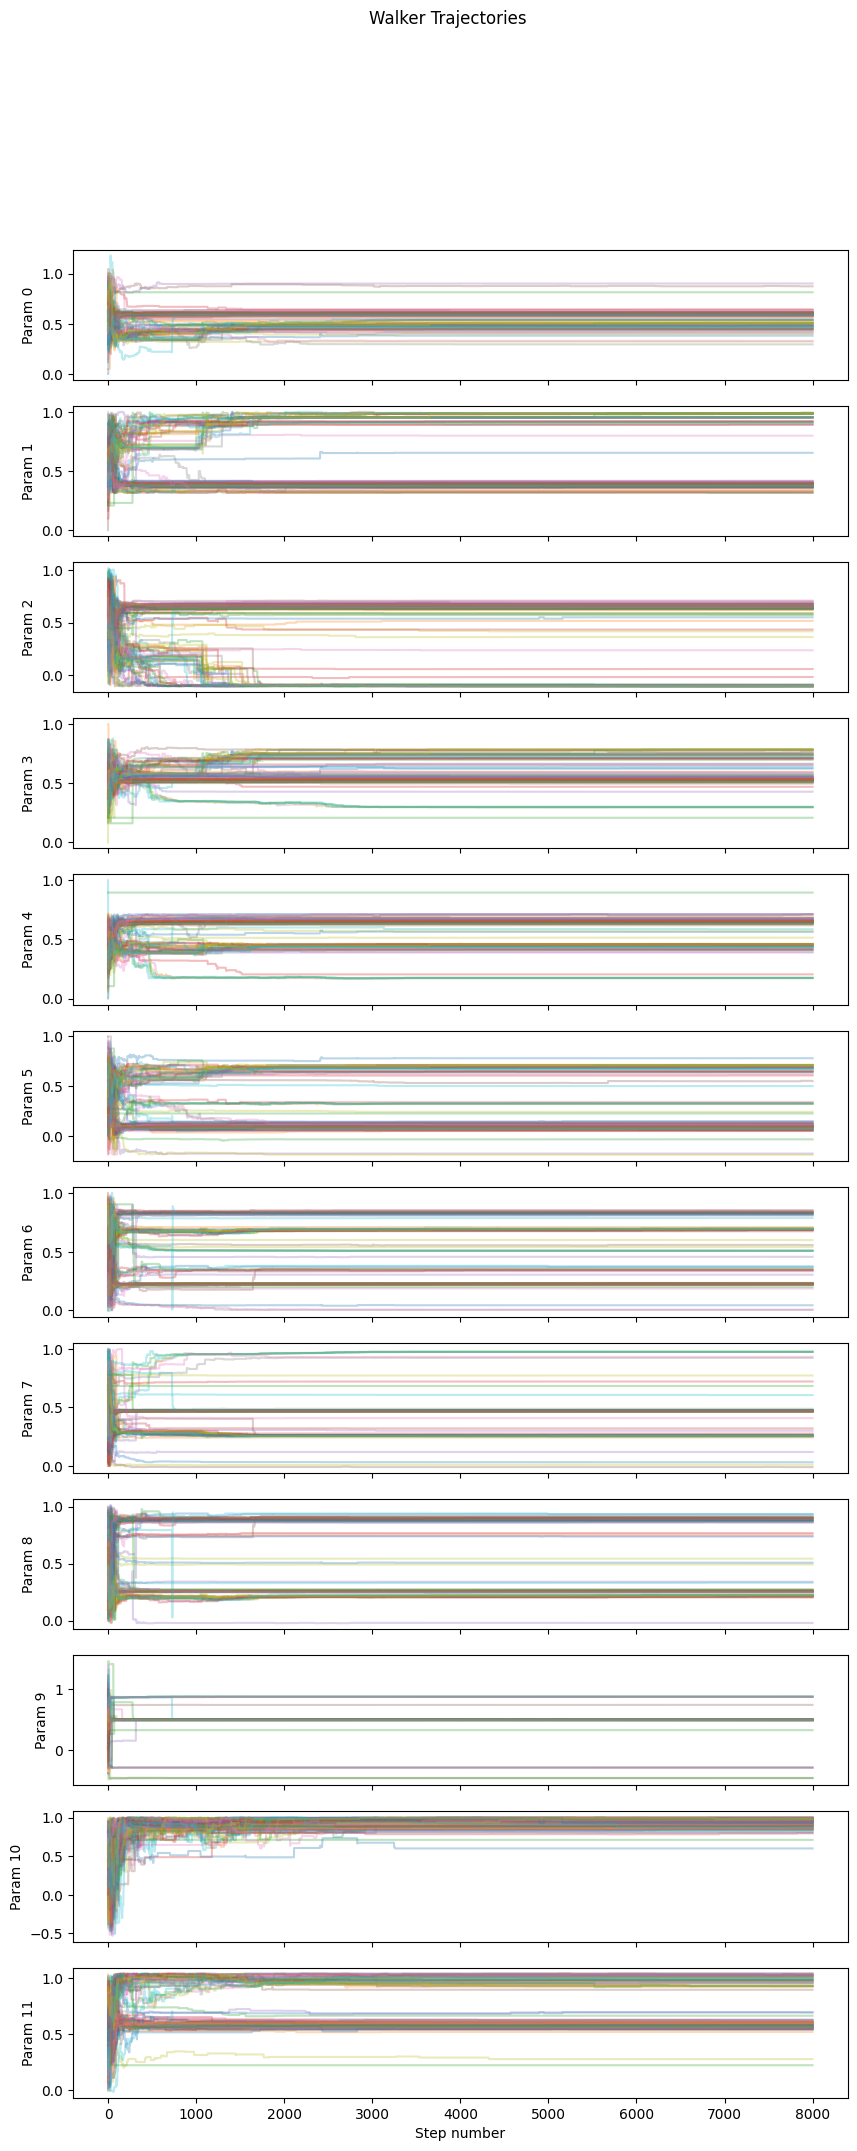

In [9]:
samples_nonflat = sampler.get_chain(flat=False, thin=10)
nsteps, nwalkers, ndim = samples_nonflat.shape
print(nwalkers, nsteps, ndim)
fig, axes = plt.subplots(ndim, figsize=(10, ndim * 2), sharex=True)
for i in range(ndim):
    for walker in range(nwalkers):
        axes[i].plot(samples_nonflat[:, walker, i], alpha=0.3)  # Plot each walker's trace
        axes[i].set_ylabel(f"Param {i}")

axes[-1].set_xlabel("Step number")
plt.suptitle("Walker Trajectories")
plt.show()


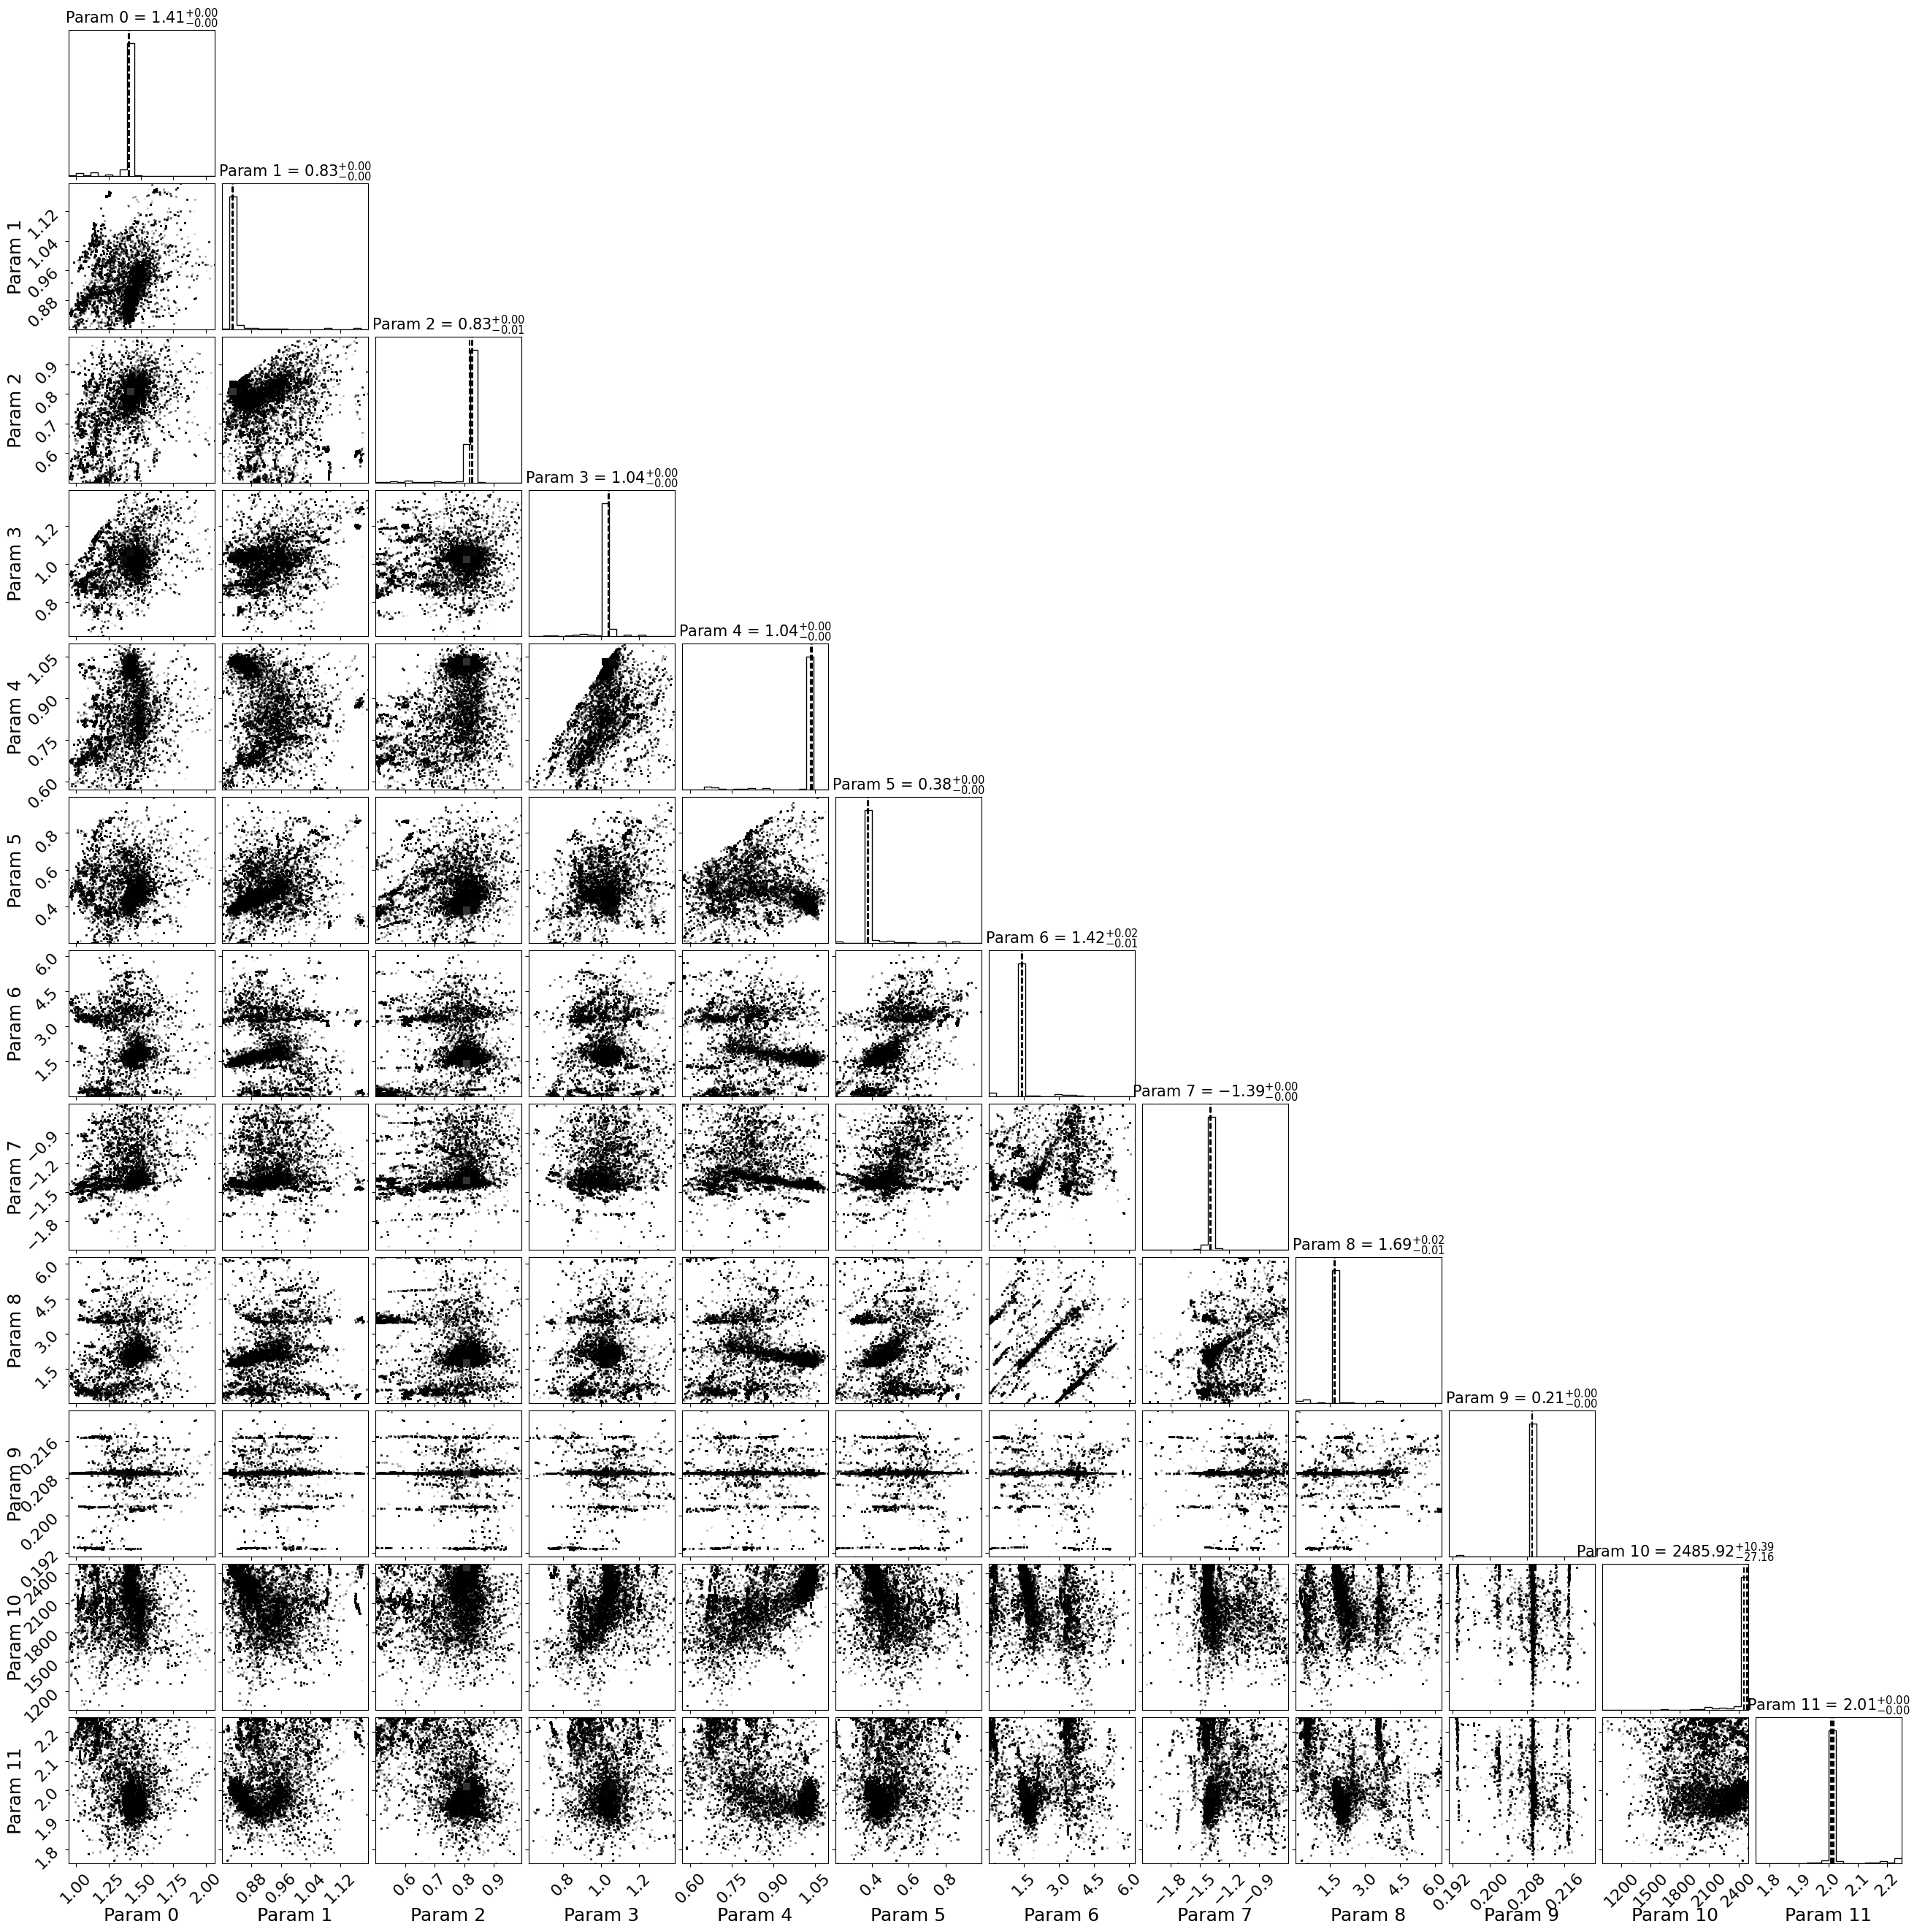

In [53]:
import corner
flat_samples = samples.reshape(-1, ndim)  # Flatten chain
fig = corner.corner(flat_samples, labels=[f"Param {i}" for i in range(ndim)],
                    quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()

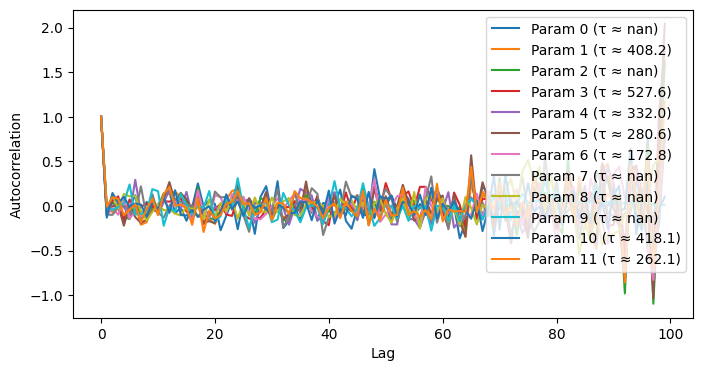

In [10]:
def autocorr_func(x, lag):
    n = len(x)
    mean = np.mean(x)
    var = np.var(x)
    x = x - mean
    return np.correlate(x, x, mode="full")[n - 1:] / (var * np.arange(n, 0, -1))

fig, ax = plt.subplots(figsize=(8, 4))
for i in range(ndim):
    tau = emcee.autocorr.integrated_time(samples_nonflat[:, :, i], tol=0)[0]
    autocorr = autocorr_func(samples_nonflat[:, :, i].mean(axis=0), lag=200)
    #print(i, tau, autocorr)
    ax.plot(autocorr, label=f"Param {i} (τ ≈ {tau:.1f})")

ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.legend()
plt.show()


/tmp/ipykernel_9514/1596352019.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1, h_pad=-0.4, w_pad=0.0)


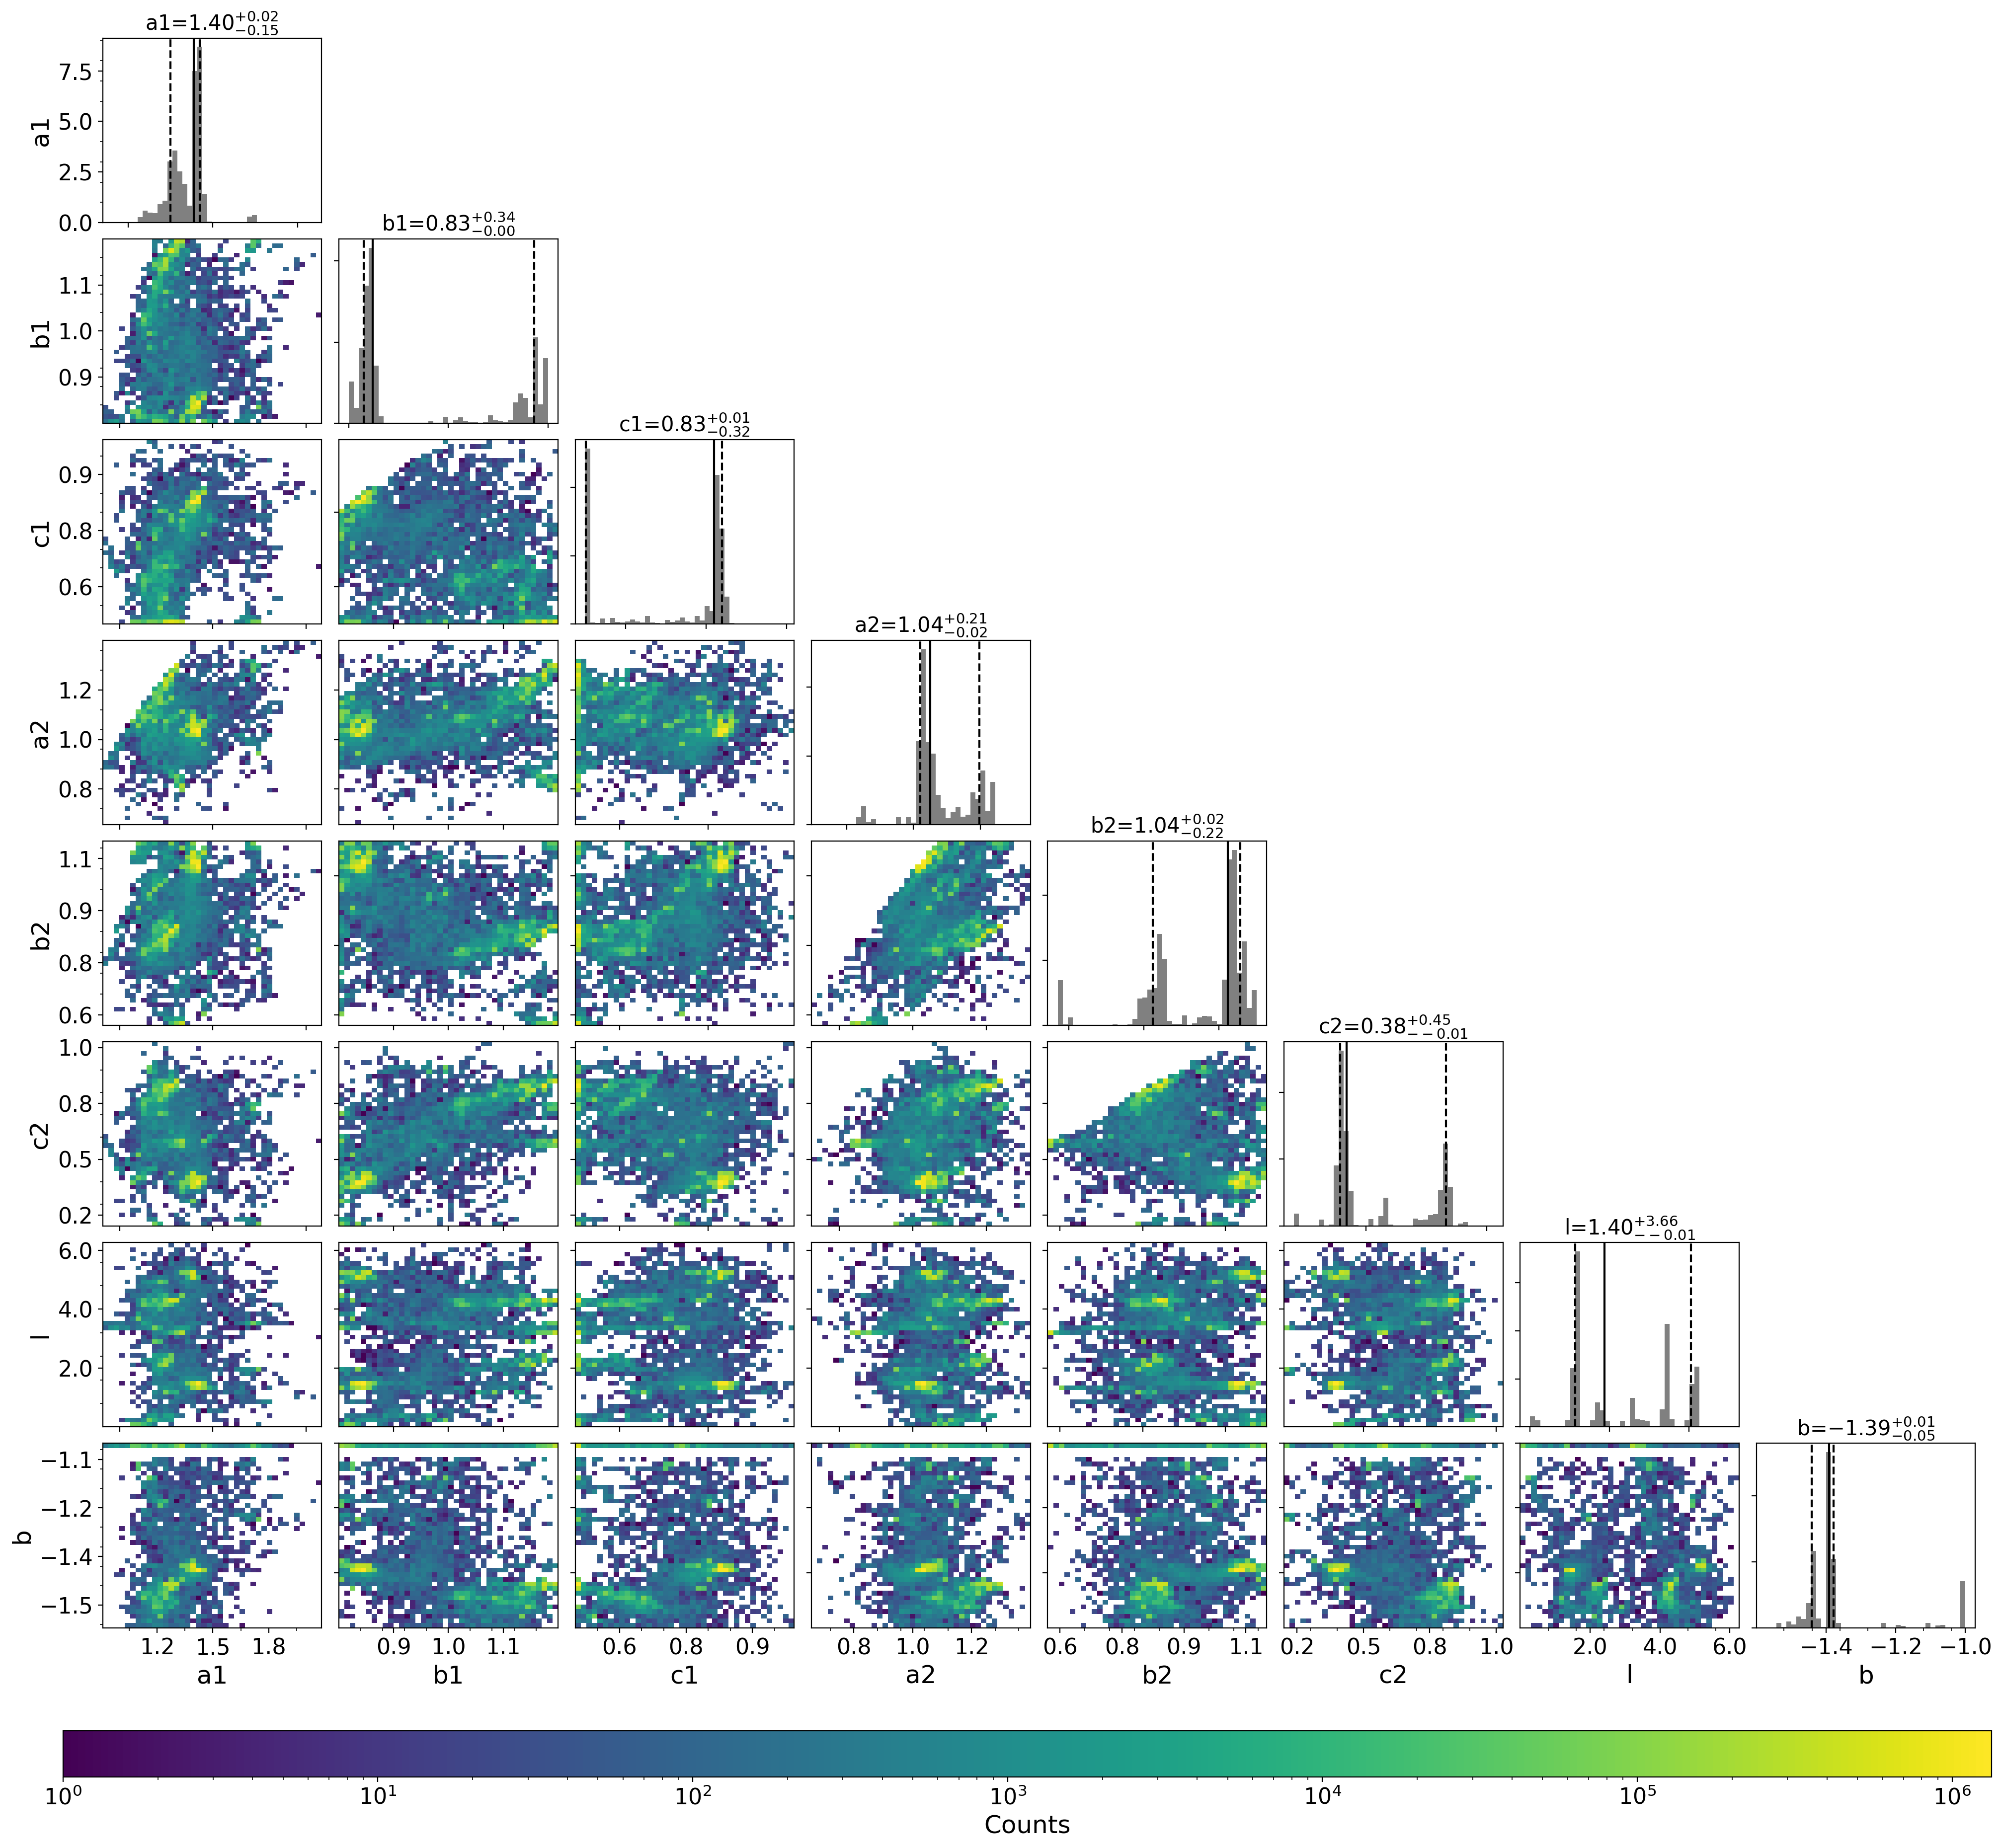

In [11]:
data = samples[:, :8]
data[:, 6:8] = func.adjust_angle(data)

num_params = data.shape[1]

labels=["a1", "b1", "c1", "a2", "b2", "c2", "l", "b", "phi0"]

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 15
# Create a figure with subplots
fig, axes = plt.subplots(num_params, num_params, figsize=(20, 20), dpi=200)
bins_heat = 40
bins_hist = 40
best_params_hist = samples_flat[min_arg]

# Variable to store the mappable object for the colorbar
mappable = None
# Plot the histograms and scatter plots
for i in range(num_params):
    for j in range(num_params):
        if i < j:
            # Skip the upper triangle and diagonal
            axes[i, j].axis('off')
        elif i == j:
            # get the desired percentiles
            data_axis = data[:, i]
            p16 = np.percentile(data_axis, q=16)
            p84 = np.percentile(data_axis, q=84)
            median = np.median(data_axis)
            # data_axis = data_axis[(data_axis >= p16) & (data_axis <= p84)]
            # Diagonal: plot histograms
            axes[i, j].hist(data_axis, bins=bins_hist, color='gray', density=True)
            axes[i, j].axvline(median, color='black')
            axes[i, j].axvline(p16, color='black', linestyle='--')
            axes[i, j].axvline(p84, color='black', linestyle='--')
            # Add title with median and percentiles
            axes[i, j].title.set_text(r'%s=${%.2f}_{-%.2f}^{+%.2f}$' % (labels[i], round(best_params_hist[i],2),
                                                                  round(best_params_hist[i]-p16, 2), abs(round(p84 - best_params_hist[i], 2))))
        else:
            # Off-diagonal: plot scatter plots
            data_j = data[:, j]
            data_i = data[:, i]
            p16j = np.percentile(data_j, q=16)
            p84j = np.percentile(data_j, q=84)
            idx_j = np.argwhere((data_j >= p16j) & (data_j <= p84j))

            #h = axes[i, j].hist2d(data_j[idx_j][:, 0], data_i[idx_j][:, 0], bins=bins_heat, cmap='viridis', norm=LogNorm())
            h = axes[i, j].hist2d(data_j, data_i, bins=bins_heat, cmap='viridis', norm=LogNorm())

            if mappable is None:
                mappable = h[3]  # Store the mappable object for the colorbar
            #axes[i, j].set_xlabel(labels[j])

        # Remove labels for cleaner look
        if i < num_params - 1:
            axes[i, j].set_xticklabels([])
        if j > 0:
            axes[i, j].set_yticklabels([])

        # Add axis labels
        if i == num_params - 1:
            axes[i, j].set_xlabel(labels[j])
            axes[i, j].xaxis.set_major_locator(ticker.MaxNLocator(4))
            axes[i, j].xaxis.set_minor_locator(ticker.MaxNLocator(10))
            axes[i, j].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))
        if j == 0:
            axes[i, j].set_ylabel(labels[i])
            axes[i, j].yaxis.set_major_locator(ticker.MaxNLocator(4))
            axes[i, j].yaxis.set_minor_locator(ticker.MaxNLocator(10))
            axes[i, j].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))


# Add a colorbar at the bottom for all subplots
if mappable:
    #cbar_ax = fig.add_axes([0.09, 0.06, 0.84, 0.02])
    cbar = fig.colorbar(mappable, ax=axes, orientation='horizontal', fraction=0.03, pad=-0.23, shrink=100.0, aspect=42)
    cbar.set_label('Counts')

#plt.legend()
# Adjust layout
plt.tight_layout(pad=0.1, h_pad=-0.4, w_pad=0.0)
#plt.savefig('article_images/correlation_mcmc.png', bbox_inches='tight', format='png')
#plt.savefig('article_images/correlation_mcmc.pdf', bbox_inches='tight', format='pdf')
plt.show()